## 0. Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

df_od = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od.csv", encoding='utf-8-sig')
df_od.shape

(833, 58)

## ONE-HOT

In [2]:
## One-Hot Encoding
CAT_COL = "market_item_type"

df_od = pd.get_dummies(
    df_od,
    columns=[CAT_COL],
    drop_first=False,
    dtype=int
)

df_od.shape

(833, 62)

## Feature Columns

In [3]:
exclude_cols = ['행정기관코드', '시장명', '시도', '시군구', '위도', '경도', '빈점포율', '총시장상인', 'pop_t', '지원금액', '지원여부']

feature_cols = [c for c in df_od.columns if c not in exclude_cols]

df_train = df_od[feature_cols + ['빈점포율']].copy()
TARGET = '빈점포율'

df_train.shape

(833, 54)

## Scatter plot

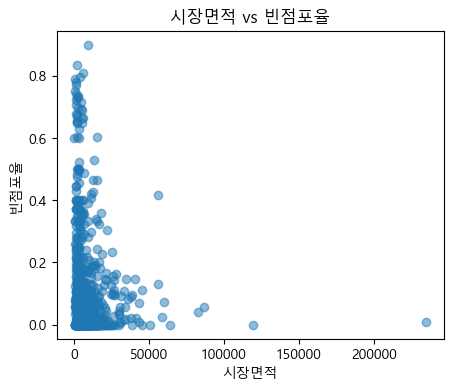

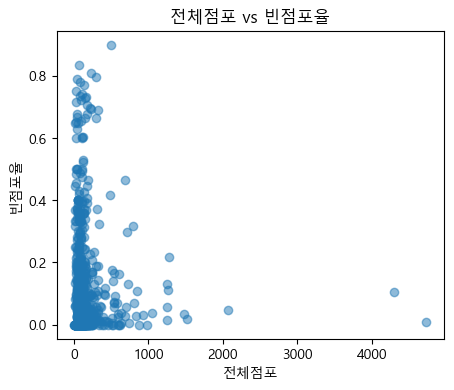

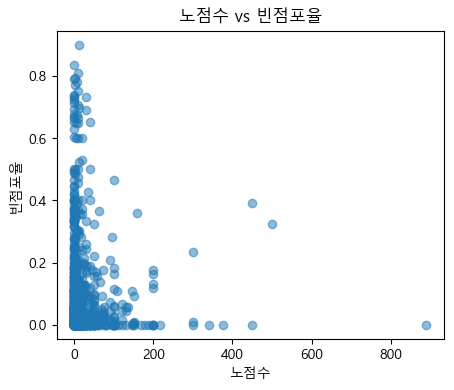

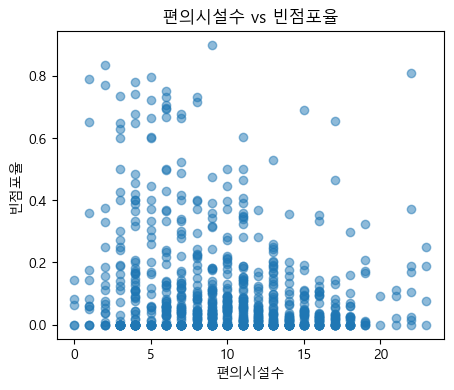

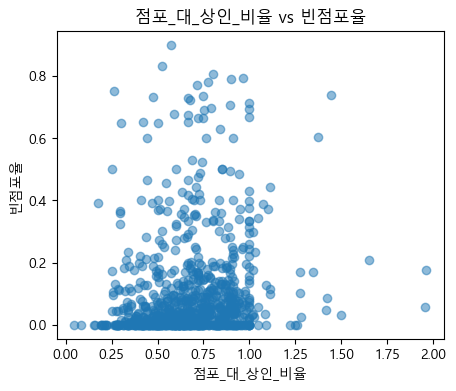

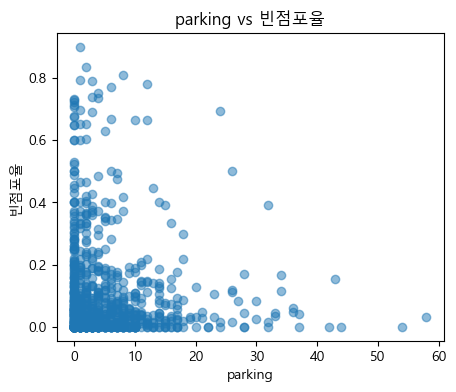

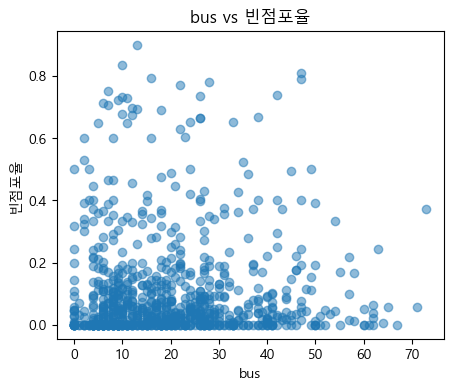

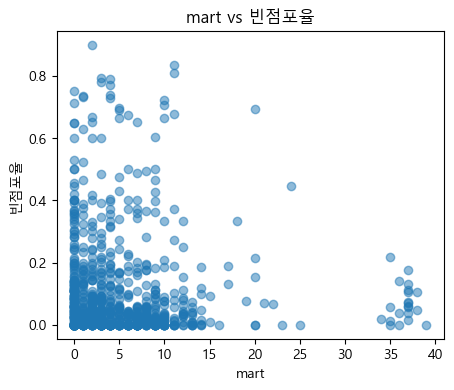

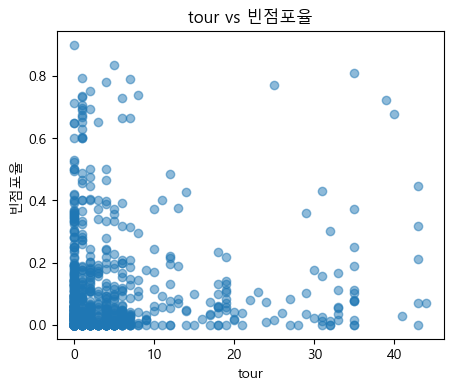

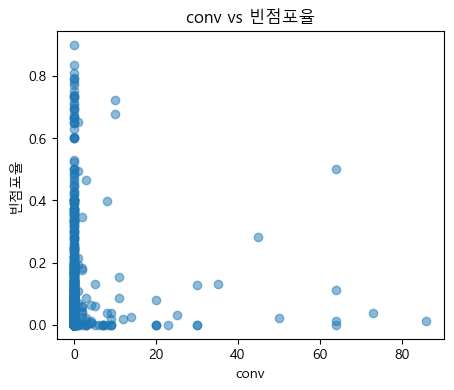

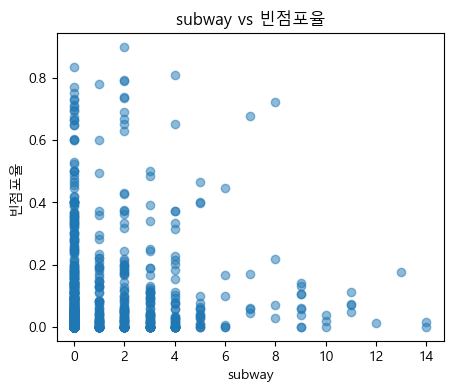

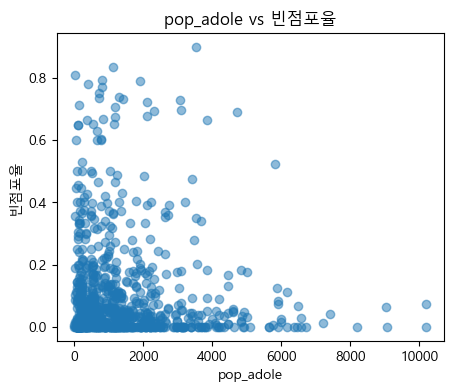

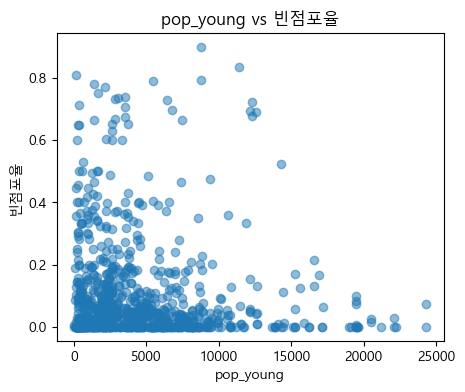

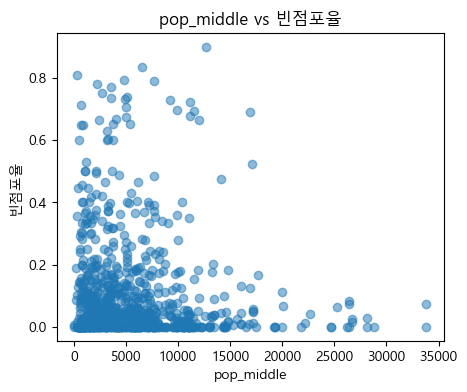

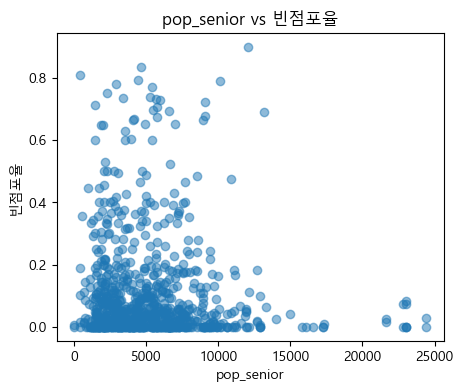

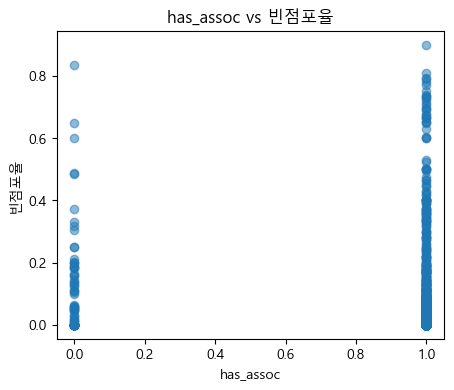

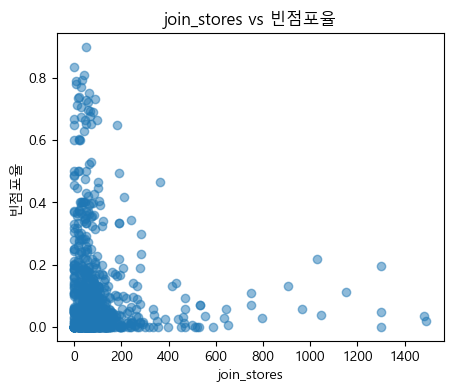

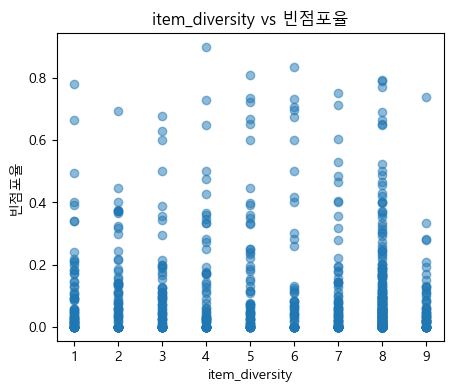

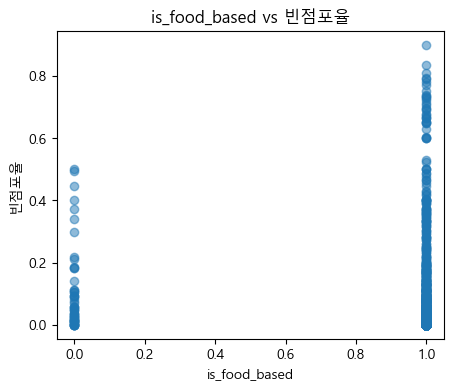

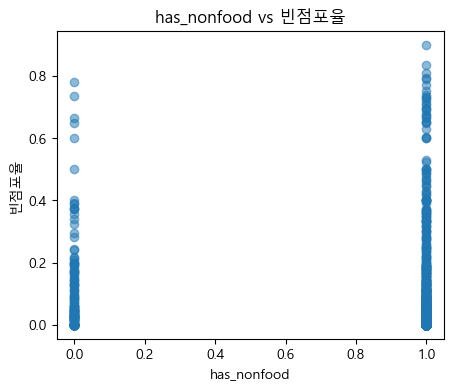

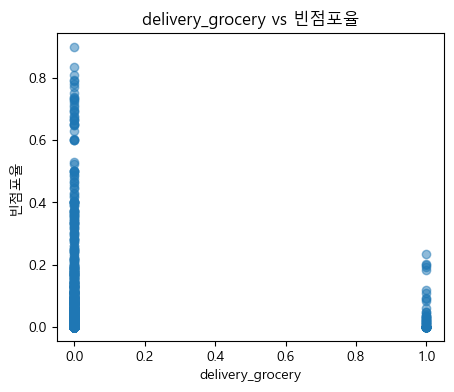

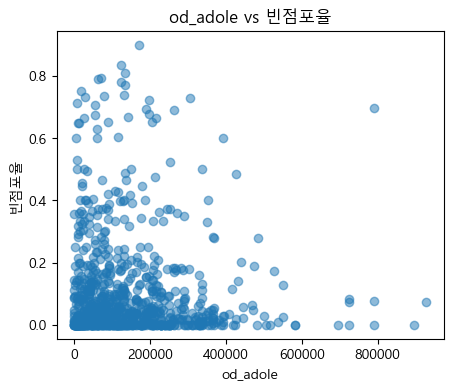

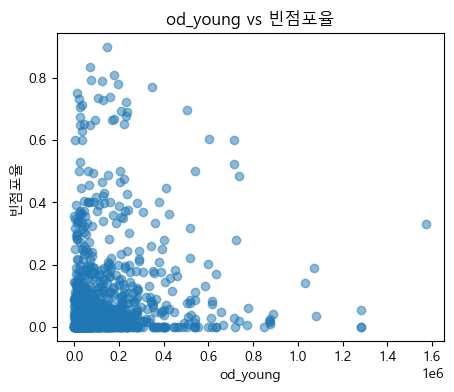

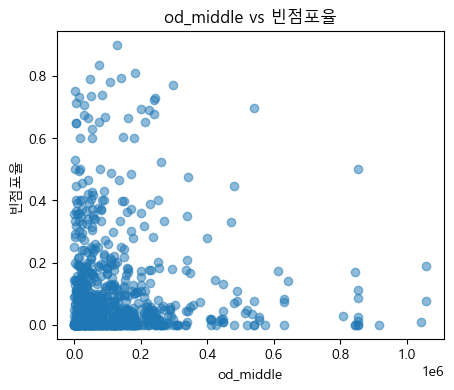

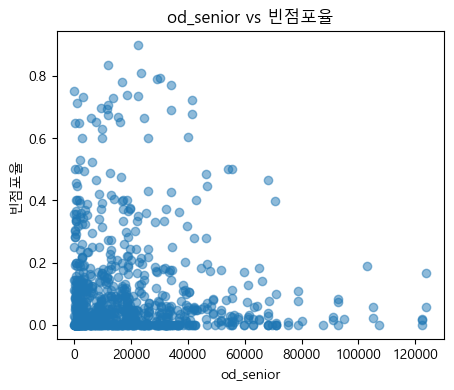

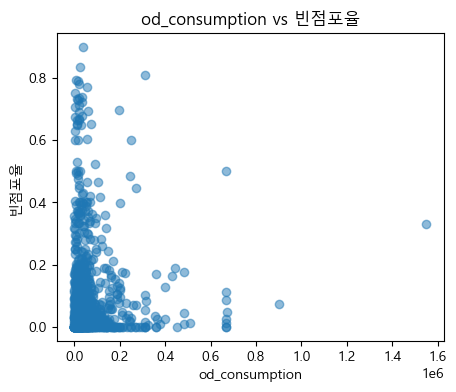

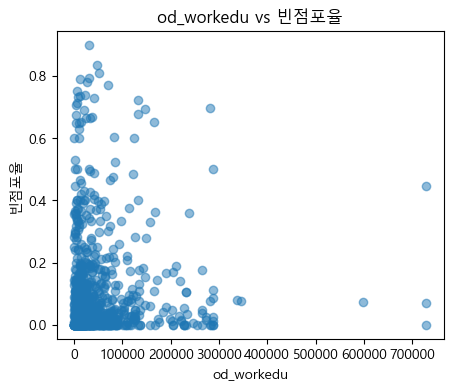

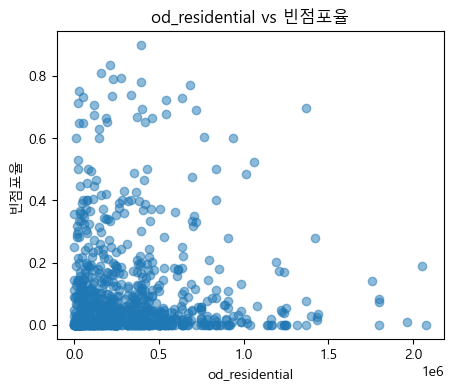

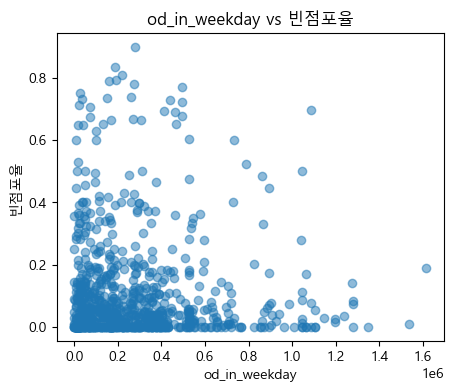

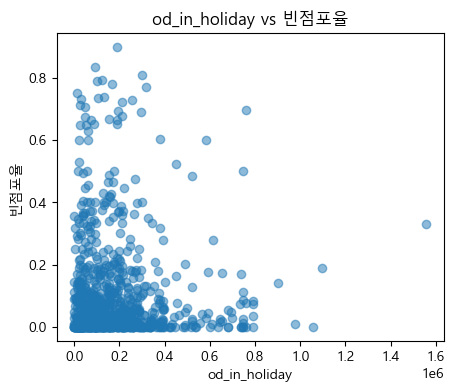

In [4]:
## 산점도(너무 많으면 시간 오래걸리니 필요시 일부만)
# 예: 앞에서 30개만
for column in feature_cols[:30]:
    plt.figure(figsize=(5,4))
    plt.scatter(df_train[column], df_train[TARGET], alpha=0.5)
    plt.xlabel(column)
    plt.ylabel(TARGET)
    plt.title(f"{column} vs {TARGET}")
    plt.show()


## oof modeling

In [10]:
from collections import Counter

random_state = 123
n_splits = 5

X_all = df_train.drop(columns=[TARGET]).copy()
y_all = df_train[TARGET].copy()

folds = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

# dt, rf, xgb, lgbm
oof_dt   = np.zeros(len(df_train))
oof_rf   = np.zeros(len(df_train))
oof_xgb  = np.zeros(len(df_train))
oof_lgbm = np.zeros(len(df_train))

In [17]:
# fold 별 선택된 변수들
fold_selected_cols = []

# fold별 모델 성능
rows = []

for fold, (tr_idx, va_idx) in enumerate(folds.split(X_all, y_all), 1):
    X_tr = X_all.iloc[tr_idx].copy()
    y_tr = y_all.iloc[tr_idx].copy()
    X_va = X_all.iloc[va_idx].copy()
    y_va = y_all.iloc[va_idx].copy()

    print(f"\n================ Fold {fold} ================")
    print("train:", X_tr.shape, "valid:", X_va.shape)

    # -----------------------------
    # (1) Spearman 상위 15 (train fold에서만)
    # -----------------------------
    tmp = pd.concat([X_tr, y_tr], axis=1)
    sp = tmp.corr(method='spearman')[TARGET].abs().sort_values(ascending=False)
    sp_top15 = [c for c in sp.index if c != TARGET][:15]
    print("[Spearman] top15:", sp_top15)

    # -----------------------------
    # (2) Feature Importance 상위 15 (train fold에서만)
    # -----------------------------
    dt_fi_model = DecisionTreeRegressor(random_state=random_state)
    dt_fi_model.fit(X_tr, y_tr)
    dt_fi = pd.Series(dt_fi_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    dt_fi_top15 = dt_fi.head(15).index.tolist()
    print("[FI-DT] top15:", dt_fi_top15)

    rf_fi_model = RandomForestRegressor(random_state=random_state, n_estimators=500, n_jobs=-1)
    rf_fi_model.fit(X_tr, y_tr)
    rf_fi = pd.Series(rf_fi_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    rf_fi_top15 = rf_fi.head(15).index.tolist()
    print("[FI-RF] top15:", rf_fi_top15)

    xgb_fi_model = XGBRegressor(random_state=random_state, n_estimators=500, max_depth=4, learning_rate=0.05)
    xgb_fi_model.fit(X_tr, y_tr)
    xgb_fi = pd.Series(xgb_fi_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    xgb_fi_top15 = xgb_fi.head(15).index.tolist()
    print("[FI-XGB] top15:", xgb_fi_top15)

    lgbm_fi_model = LGBMRegressor(random_state=random_state, n_estimators=500, learning_rate=0.05)
    lgbm_fi_model.fit(X_tr, y_tr)
    lgbm_fi = pd.Series(lgbm_fi_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    lgbm_fi_top15 = lgbm_fi.head(15).index.tolist()
    print("[FI-LGBM] top15:", lgbm_fi_top15)


    # -----------------------------
    # (3) 투표로 상위 12개 변수 선정
    # -----------------------------
    all_lists = (
        sp_top15
        + dt_fi_top15 + rf_fi_top15 + xgb_fi_top15 + lgbm_fi_top15
    #    + dt_sw_top15 + rf_sw_top15 + xgb_sw_top15 + lgbm_sw_top15
    )

    cnt = Counter(all_lists)
    voted12 = [x for x, _ in cnt.most_common(10)]
    print("\n[FINAL] voted12:", voted12)

    fold_selected_cols.append(voted12)

    # -----------------------------
    # (4) 선택된 12개로 모델 4개 학습 → valid 예측 (OOF 저장)
    # -----------------------------
    # DT
    dt_model = DecisionTreeRegressor(random_state=random_state)
    dt_model.fit(X_tr[voted12], y_tr)
    pred_dt = dt_model.predict(X_va[voted12])
    oof_dt[va_idx] = pred_dt

    # RF
    rf_model = RandomForestRegressor(random_state=random_state, n_estimators=500, n_jobs=-1)
    rf_model.fit(X_tr[voted12], y_tr)
    pred_rf = rf_model.predict(X_va[voted12])
    oof_rf[va_idx] = pred_rf

    # XGB
    xgb_model = XGBRegressor(random_state=random_state, n_estimators=500, max_depth=4, learning_rate=0.05)
    xgb_model.fit(X_tr[voted12], y_tr)
    pred_xgb = xgb_model.predict(X_va[voted12])
    oof_xgb[va_idx] = pred_xgb

    # LGBM
    lgbm_model = LGBMRegressor(random_state=random_state, n_estimators=800, learning_rate=0.03, num_leaves=31)
    lgbm_model.fit(X_tr[voted12], y_tr)
    pred_lgbm = lgbm_model.predict(X_va[voted12])
    oof_lgbm[va_idx] = pred_lgbm

    # -----------------------------
    # (5) fold 성능 기록 (RMSE, MAE, R2)
    # -----------------------------

    def _rmse(a, b):
        return np.sqrt(mean_squared_error(a, b))
    
    def _nmae(mae, val):
        return mae / np.mean(val)

    rows.append({"fold": fold, "model": "DT", "NMAE": _nmae(mean_absolute_error(y_va, pred_dt), y_va),
                 "RMSE": _rmse(y_va, pred_dt), "MAE": mean_absolute_error(y_va, pred_dt), "R2": r2_score(y_va, pred_dt)})
    rows.append({"fold": fold, "model": "RF", "NMAE": _nmae(mean_absolute_error(y_va, pred_rf), y_va),
                 "RMSE": _rmse(y_va, pred_rf), "MAE": mean_absolute_error(y_va, pred_rf), "R2": r2_score(y_va, pred_rf)})
    rows.append({"fold": fold, "model": "XGB", "NMAE": _nmae(mean_absolute_error(y_va, pred_xgb), y_va),
                 "RMSE": _rmse(y_va, pred_xgb), "MAE": mean_absolute_error(y_va, pred_xgb), "R2": r2_score(y_va, pred_xgb)})
    rows.append({"fold": fold, "model": "LGBM", "NMAE": _nmae(mean_absolute_error(y_va, pred_lgbm), y_va),
                 "RMSE": _rmse(y_va, pred_lgbm), "MAE": mean_absolute_error(y_va, pred_lgbm), "R2": r2_score(y_va, pred_lgbm)})

    print(f"\n[Fold {fold}] RMSE  DT={_rmse(y_va, pred_dt):.4f} | RF={_rmse(y_va, pred_rf):.4f} | XGB={_rmse(y_va, pred_xgb):.4f} | LGBM={_rmse(y_va, pred_lgbm):.4f}")



================ Fold 1 ================
train: (666, 53) valid: (167, 53)
[Spearman] top15: ['점포_대_상인_비율', 'delivery_grocery', '편의시설수', '시장면적', '노점수', 'pop_young', 'join_stores', 'pop_middle', 'pop_adole', 'stay_residential', 'stay_night', 'od_modal_etc', 'stay_holiday', 'stay_evening', 'stay_young']
[FI-DT] top15: ['시장면적', '편의시설수', '전체점포', 'pop_young', '점포_대_상인_비율', 'tour', 'pop_middle', 'od_modal_sub', 'od_consumption', 'join_stores', 'bus', 'stay_holiday', 'od_middle', 'od_young', 'pop_senior']
[FI-RF] top15: ['시장면적', '전체점포', 'join_stores', '편의시설수', '점포_대_상인_비율', 'stay_consumption', 'pop_young', 'tour', 'bus', '노점수', 'pop_senior', 'od_consumption', 'od_senior', 'pop_adole', 'od_young']
[FI-XGB] top15: ['편의시설수', 'stay_night', 'join_stores', 'market_item_type_생활형(장보기형)', '전체점포', 'stay_consumption', 'pop_young', '시장면적', 'od_in_weekday', 'od_modal_etc', 'stay_adole', 'stay_residential', 'od_modal_sub', 'od_young', '노점수']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the ov

## 성능 비교 & 최종 모델

In [19]:
oof_result = pd.DataFrame(rows)

# fold별 성능 확인
oof_result.sort_values(["fold", "NMAE"]).head(12)

# 모델별 평균 성능(OOF)
summary = (
    oof_result.groupby("model")[["NMAE","RMSE","MAE","R2"]]
    .mean()
    .sort_values("MAE")
)
summary


,NMAE,RMSE,MAE,R2
model,,,,
XGB,0.942386,0.148359,0.099982,0.170237
RF,0.952549,0.147006,0.100935,0.185384
LGBM,0.958955,0.149474,0.101821,0.161655
DT,1.193117,0.201190,0.125339,-0.575300


In [20]:
best_model_name = summary.index[0]
best_model_name


'XGB'

In [21]:
df_train_oof = df_train.copy()

df_train_oof["oof_DT"]   = oof_dt
df_train_oof["oof_RF"]   = oof_rf
df_train_oof["oof_XGB"]  = oof_xgb
df_train_oof["oof_LGBM"] = oof_lgbm

# best 모델의 OOF pred를 pred로 확정
if best_model_name == "DT":
    df_train_oof["pred"] = df_train_oof["oof_DT"]
elif best_model_name == "RF":
    df_train_oof["pred"] = df_train_oof["oof_RF"]
elif best_model_name == "XGB":
    df_train_oof["pred"] = df_train_oof["oof_XGB"]
else:
    df_train_oof["pred"] = df_train_oof["oof_LGBM"]

# OOF residual (핵심)
df_train_oof["residual"] = df_train_oof[TARGET] - df_train_oof["pred"]

df_train_oof[["pred","residual"]].describe()


,pred,residual
count,833.000000,833.000000
mean,0.104368,0.001892
std,0.096455,0.149214
min,-0.082679,-0.366796
25%,0.041919,-0.072306
50%,0.080635,-0.022684
75%,0.138789,0.039269
max,0.901759,0.755319


In [22]:
# df_od와 df_train_oof는 행 순서가 같아야 한다는 전제
# 혹시 정렬/필터가 중간에 있었다면, index를 먼저 맞춰야 함

df_od_out = df_od.copy()
df_od_out["pred"] = df_train_oof["pred"].values
df_od_out["residual"] = df_train_oof["residual"].values

df_od_out[["빈점포율","pred","residual"]].head()

,빈점포율,pred,residual
0,0.044444,0.124966,-0.080522
1,0.000000,0.002011,-0.002011
2,0.038462,-0.019784,0.058245
3,0.011905,0.035938,-0.024033
4,0.258065,0.091318,0.166746


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_od_out[["z_vacancy", "z_residual"]] = scaler.fit_transform(
    df_od_out[["빈점포율", "residual"]]
)

# risk_index
alpha = 0.5
df_od_out["risk_index"] = alpha * df_od_out["z_vacancy"] + (1 - alpha) * df_od_out["z_residual"]


df_od_out[["빈점포율","pred","residual","risk_index"]].describe()

,빈점포율,pred,residual,risk_index
count,833.000000,833.000000,833.000000,8.330000e+02
mean,0.106260,0.104368,0.001892,-2.985474e-17
std,0.164211,0.096455,0.149214,9.531322e-01
min,0.000000,-0.082679,-0.366796,-1.559923e+00
25%,0.000000,0.041919,-0.072306,-5.027585e-01
50%,0.039474,0.080635,-0.022684,-3.051475e-01
75%,0.130435,0.138789,0.039269,1.595691e-01
max,0.900000,0.901759,0.755319,4.741339e+00


## 지도 시각화

In [31]:
# 위험 상위 30%를 high-risk로
q = df_od_out["risk_index"].quantile(0.8)
df_od_out["risk_group"] = np.where(df_od_out["risk_index"] >= q, "HIGH", "NORMAL")

df_od_out["risk_group"].value_counts()

risk_group
NORMAL    666
HIGH      167
Name: count, dtype: int64

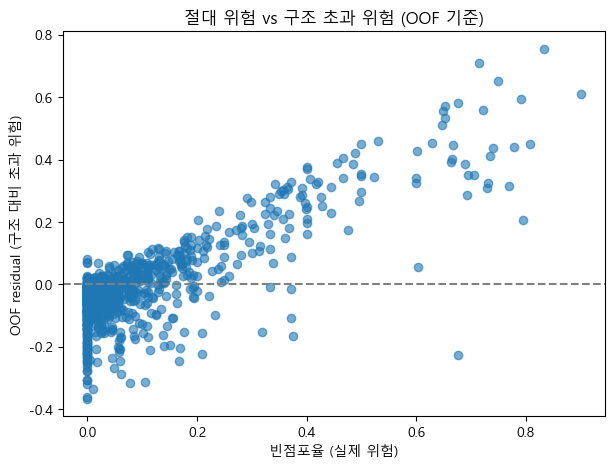

In [32]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_od_out["빈점포율"],
    df_od_out["residual"],
    alpha=0.6
)

plt.axhline(0, linestyle="--", color="gray")

plt.xlabel("빈점포율 (실제 위험)")
plt.ylabel("OOF residual (구조 대비 초과 위험)")
plt.title("절대 위험 vs 구조 초과 위험 (OOF 기준)")

plt.show()


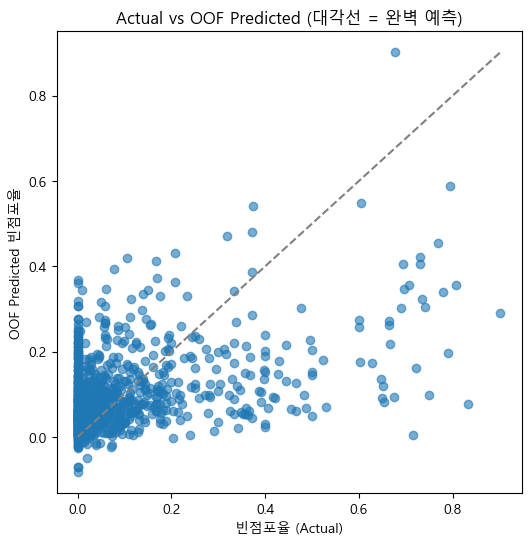

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(
    df_od_out["빈점포율"],
    df_od_out["pred"],
    alpha=0.6
)

max_val = max(df_od_out["빈점포율"].max(), df_od_out["pred"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray")

plt.xlabel("빈점포율 (Actual)")
plt.ylabel("OOF Predicted 빈점포율")
plt.title("Actual vs OOF Predicted (대각선 = 완벽 예측)")

plt.show()


In [35]:
x_cut = df_od_out["빈점포율"].median()
print("x_cut (median):", x_cut)

# 사분면 라벨링
df_od_out["quadrant"] = ""

# 우상단: 절대위험 높고(residual>0), 구조초과위험도 높음
df_od_out.loc[(df_od_out["빈점포율"] >= x_cut) & (df_od_out["residual"] > 0), "quadrant"] = "Q1_우상(최우선위험)"

# 좌상단: 절대위험은 낮/중인데(residual>0), 구조적으로 취약 → 조기경보
df_od_out.loc[(df_od_out["빈점포율"] <  x_cut) & (df_od_out["residual"] > 0), "quadrant"] = "Q2_좌상(조기경보)"

# 좌하단: 절대위험 낮고, 구조적으로도 안정
df_od_out.loc[(df_od_out["빈점포율"] <  x_cut) & (df_od_out["residual"] <= 0), "quadrant"] = "Q3_좌하(안정)"

# 우하단: 절대위험은 높은데, 구조 대비는 양호(지원효과/운영역량 가능성)
df_od_out.loc[(df_od_out["빈점포율"] >= x_cut) & (df_od_out["residual"] <= 0), "quadrant"] = "Q4_우하(잠재/개입효과)"

df_od_out["quadrant"].value_counts()


x_cut (median): 0.0394736842105263


quadrant
Q3_좌하(안정)         362
Q1_우상(최우선위험)      268
Q4_우하(잠재/개입효과)    149
Q2_좌상(조기경보)        54
Name: count, dtype: int64

In [36]:
cols_show = ["시장명", "시도", "시군구", "지원여부", "빈점포율", "pred", "residual", "quadrant"]

q1_list = df_od_out[df_od_out["quadrant"]=="Q1_우상(최우선위험)"][cols_show].sort_values(["빈점포율","residual"], ascending=False).head(20)
q2_list = df_od_out[df_od_out["quadrant"]=="Q2_좌상(조기경보)"][cols_show].sort_values(["residual"], ascending=False).head(20)
q3_list = df_od_out[df_od_out["quadrant"]=="Q3_좌하(안정)"][cols_show].sort_values(["빈점포율","residual"], ascending=True).head(20)
q4_list = df_od_out[df_od_out["quadrant"]=="Q4_우하(잠재/개입효과)"][cols_show].sort_values(["빈점포율","residual"], ascending=[False, True]).head(20)

q1_list


,시장명,시도,시군구,지원여부,빈점포율,pred,residual,quadrant
733,반야월종합시장,대구광역시,동구,0.0,0.900000,0.290105,0.609895,Q1_우상(최우선위험)
111,등마루시장,서울특별시,강서구,0.0,0.833333,0.078014,0.755319,Q1_우상(최우선위험)
271,아리랑거리,부산광역시,중구,0.0,0.807692,0.356759,0.450933,Q1_우상(최우선위험)
90,신림중앙시장,서울특별시,관악구,0.0,0.794521,0.587065,0.207456,Q1_우상(최우선위험)
238,망미새상가시장,부산광역시,수영구,0.0,0.790698,0.195816,0.594882,Q1_우상(최우선위험)
786,중평시장,대구광역시,서구,0.0,0.779221,0.339583,0.439638,Q1_우상(최우선위험)
282,우암골목시장,부산광역시,남구,0.0,0.769231,0.453991,0.315239,Q1_우상(최우선위험)
324,마천시장,경상남도,창원시,0.0,0.750000,0.098615,0.651385,Q1_우상(최우선위험)
235,연미새시장,부산광역시,연제구,0.0,0.740000,0.303892,0.436108,Q1_우상(최우선위험)
743,대명중앙시장,대구광역시,남구,0.0,0.734177,0.323759,0.410419,Q1_우상(최우선위험)


In [37]:
# 지원여부 정리(0/1로 맞추기)
# 이미 0/1이면 그대로
# 'Y'/'N'이면 변환
if df_od_out["지원여부"].dtype == "object":
    df_od_out["지원여부_bin"] = df_od_out["지원여부"].map({"Y":1, "N":0, "y":1, "n":0}).fillna(df_od_out["지원여부"])
else:
    df_od_out["지원여부_bin"] = df_od_out["지원여부"]

df_od_out["지원여부_bin"].value_counts(dropna=False)


지원여부_bin
0.0    732
1.0    101
Name: count, dtype: int64

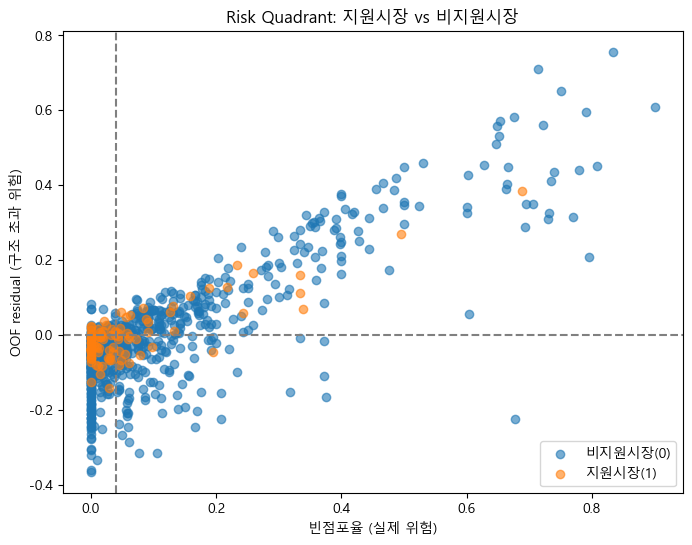

In [38]:
plt.figure(figsize=(8,6))

# 비지원(0)
df0 = df_od_out[df_od_out["지원여부_bin"]==0]
plt.scatter(df0["빈점포율"], df0["residual"], alpha=0.6, label="비지원시장(0)")

# 지원(1)
df1 = df_od_out[df_od_out["지원여부_bin"]==1]
plt.scatter(df1["빈점포율"], df1["residual"], alpha=0.6, label="지원시장(1)")

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(x_cut, linestyle="--", color="gray")

plt.xlabel("빈점포율 (실제 위험)")
plt.ylabel("OOF residual (구조 초과 위험)")
plt.title("Risk Quadrant: 지원시장 vs 비지원시장")
plt.legend()
plt.show()


In [39]:
early_warning_top10 = (
    df_od_out[df_od_out["quadrant"]=="Q2_좌상(조기경보)"][cols_show]
    .sort_values("residual", ascending=False)
    .head(10)
)

early_warning_top10


,시장명,시도,시군구,지원여부,빈점포율,pred,residual,quadrant
95,한아름시장,서울특별시,광진구,0.0,0.000000,-0.082679,0.082679,Q2_좌상(조기경보)
93,우림시장,서울특별시,관악구,0.0,0.000000,-0.070166,0.070166,Q2_좌상(조기경보)
695,덕양시장,전라남도,여수시,0.0,0.000000,-0.069481,0.069481,Q2_좌상(조기경보)
766,용산종합큰시장,대구광역시,달서구,0.0,0.019608,-0.048623,0.068231,Q2_좌상(조기경보)
2,수암종합시장,울산광역시,남구,0.0,0.038462,-0.019784,0.058245,Q2_좌상(조기경보)
60,동서시장,서울특별시,동대문구,0.0,0.038462,-0.013177,0.051639,Q2_좌상(조기경보)
495,상주중앙시장,경상북도,상주시,1.0,0.020548,-0.016651,0.037199,Q2_좌상(조기경보)
571,동신종합시장,경기도,성남시,0.0,0.034483,0.004879,0.029604,Q2_좌상(조기경보)
42,신중앙시장,서울특별시,중구,0.0,0.037736,0.009227,0.028508,Q2_좌상(조기경보)
104,돈암시장,서울특별시,성북구,0.0,0.027273,0.001560,0.025712,Q2_좌상(조기경보)


In [43]:
quad_summary = (
    df_od_out.groupby("quadrant")
    .agg(
        n=("시장명","count"),
        vacancy_mean=("빈점포율","mean"),
        residual_mean=("residual","mean"),
        support_rate=("지원여부_bin","mean")
    )
    .sort_index()
    #.sort_values("n", ascending=False)
)

quad_summary


,n,vacancy_mean,residual_mean,support_rate
quadrant,,,,
Q1_우상(최우선위험),268,0.260897,0.154304,0.089552
Q2_좌상(조기경보),54,0.016495,0.019802,0.259259
Q3_좌하(안정),362,0.007580,-0.078674,0.138122
Q4_우하(잠재/개입효과),149,0.100401,-0.082998,0.087248


In [44]:
df_od_out.to_csv(
    r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od_all_oof.csv",
    encoding="utf-8-sig",
    index=False
)